# Tests Rapides de Modèles par transfert Learning

Nous allons tester des modeles entraine sur Imagenet et Open Image
https://github.com/google/automl/tree/master/efficientdet
EfficientDet / EfficientNet (Google)

In [10]:
import psutil
import tensorflow as tf
from tensorflow.keras import layers

import sys,os
# Ajouter src au chemin de recherche des modules
notebook_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
	sys.path.append(src_path)
import image_search
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping






In [11]:
print("version tensorflow: {}".format(tf.__version__))
print("Mémoire totale :", psutil.virtual_memory().total / (1024**3), "GB")
print("Utilisation CPU :", psutil.cpu_percent(interval=1), "%")

for disk in psutil.disk_partitions():
    print("Type :", disk.fstype)
    print("Monté sur :", disk.mountpoint)
    print("-" * 30)

version tensorflow: 2.19.0
Mémoire totale : 15.691375732421875 GB
Utilisation CPU : 39.2 %
Type : NTFS
Monté sur : C:\
------------------------------


## MobileNetV2

Les réseaux neuronaux convolutifs ont démontré des performances remarquables dans des tâches de vision par ordinateur telles que la classification d'images, la détection d'objets et la segmentation sémantique. Cependant, les architectures CNN traditionnelles, comme VGG, ResNet ou Inception, sont souvent caractérisées par un grand nombre de paramètres (nous les testerons ...) et une complexité computationnelle élevée. Cette complexité les rend gourmands en ressources et difficilement déployables sur des appareils à ressources limitées.

C'est précisément là que MobileNet intervient. Développé par Google, MobileNet représente une famille d'architectures de réseaux neuronaux convolutifs conçues spécifiquement pour des applications sur appareils mobiles et embarqués, où la consommation d'énergie, la latence et la taille du modèle sont des contraintes critiques. L'objectif fondamental de MobileNet est de permettre le déploiement de modèles de vision par ordinateur sophistiqués sur des plateformes telles que les smartphones, les drones, les véhicules autonomes, les dispositifs IoT et d'autres systèmes edge computing, sans compromettre significativement la précision.

La philosophie derrière MobileNet est de concevoir des réseaux qui sont à la fois légers  et efficaces
En utilisant des poids pré-entraînés sur ImageNet, MobileNetV2 peut reconnaître des formes et textures génériques dès les premières couches, avant d'être adapté aux particularités notre dataset. En combinant sa légèreté et son efficacité avec un fine-tuning sur nos images, on peut obtenir un modèle performant qui conserve une bonne précision sans exiger une puissance de calcul excessive.


### 1. changement des images : 10 races

In [12]:
images_dir = '../data/images_transf_256x256'  
list_dir = '../data/lists'  

df_train, df_test = image_search.load_train_test_split_mat(
    images_dir=images_dir,
    list_dir=list_dir,
    max_races=10
)


### 2. Conversion en tableaux NumPy

In [13]:
X_train, y_train = image_search.images_to_numpy(df_train)
X_test, y_test = image_search.images_to_numpy(df_test)
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")


X_train shape: (1000, 256, 256, 3), dtype: uint8
X_test shape: (919, 256, 256, 3), dtype: uint8


### 3.Encodage des labels

In [14]:
# Conversion des labels en int
# LabelEncoder assigne un numéro unique à chaque classe
label_encoder = sklearn.preprocessing.LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

# Transformation des labels entiers en représentation one-hot
# Nécessaire pour  softmax en sortie
# Format one-hot : [1, 0, 0] = classe 0, [0, 1, 0] = classe 1, etc.

y_train_cat = tf.keras.utils.to_categorical(y_train_int)
y_test_cat = tf.keras.utils.to_categorical(y_test_int)


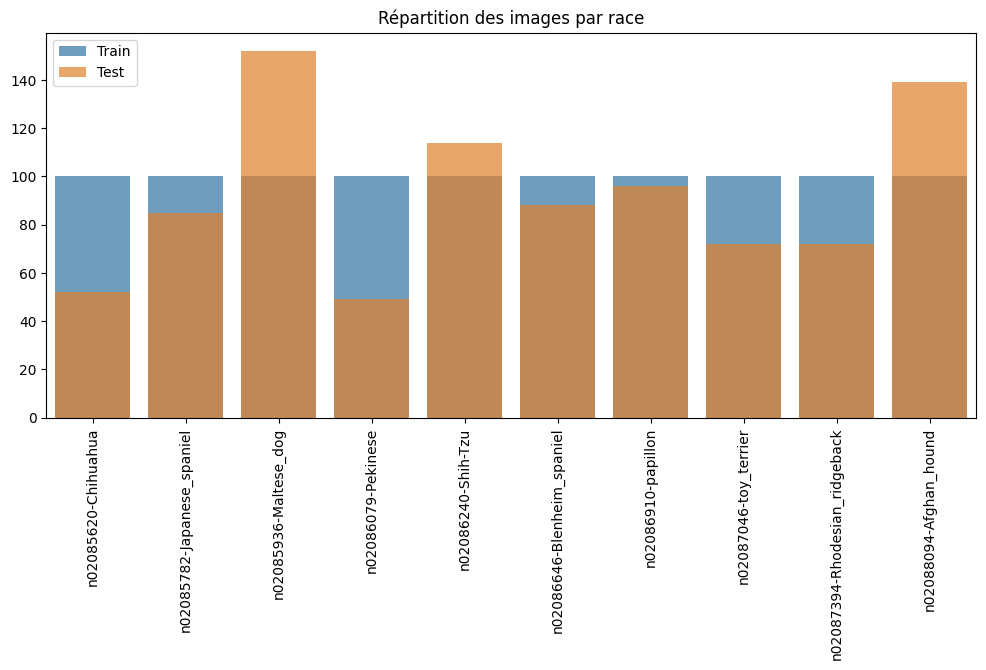

In [15]:
train_counts = {cls: sum(y_train == cls) for cls in np.unique(y_train)}
test_counts = {cls: sum(y_test == cls) for cls in np.unique(y_test)}
plt.figure(figsize=(12, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), alpha=0.7, label="Train")
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), alpha=0.7, label="Test")
plt.xticks(rotation=90)
plt.legend()
plt.title("Répartition des images par race")
plt.show()

### Initialisation du modéle

In [16]:

# Charge le modèle MobileNetV2 pré-entraîné sur ImageNet.
# 'include_top=False' exclut les couches de classification originales.
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=X_train.shape[1:])

# Gèle les poids du modèle de base. Cela empêche leur modification pendant l'entraînement initial,
# utilisant ses capacités d'extraction de caractéristiques sans les altérer.
base_model.trainable = False


C:\Users\HP\AppData\Local\Temp\ipykernel_10880\2790652016.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=X_train.shape[1:])


In [18]:

# Construction du modèle complet
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Réduction de la dimension spatiale
    layers.Dropout(0.3),  # Prévention du sur-apprentissage
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),  # Normalisation pour stabiliser l'entraînement
    layers.Dropout(0.3),
    layers.Dense(len(label_encoder.classes_), activation='softmax')  
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks 

# Définit un callback pour l'arrêt anticipé de l'entraînement.
# Arrête si 'val_loss' ne s'améliore pas pendant 3 époques et restaure les meilleurs poids.
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entraînement du modèle
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/20
32/32 - 50s - 2s/step - accuracy: 0.1570 - loss: 2.8591 - val_accuracy: 0.2002 - val_loss: 2.2294
Epoch 2/20
32/32 - 36s - 1s/step - accuracy: 0.2380 - loss: 2.2648 - val_accuracy: 0.2122 - val_loss: 2.3185
Epoch 3/20
32/32 - 37s - 1s/step - accuracy: 0.2940 - loss: 2.1092 - val_accuracy: 0.2622 - val_loss: 2.0980
Epoch 4/20
32/32 - 38s - 1s/step - accuracy: 0.3300 - loss: 1.9512 - val_accuracy: 0.3493 - val_loss: 1.8378
Epoch 5/20
32/32 - 42s - 1s/step - accuracy: 0.3550 - loss: 1.7979 - val_accuracy: 0.3569 - val_loss: 1.8214
Epoch 6/20
32/32 - 38s - 1s/step - accuracy: 0.3930 - loss: 1.7324 - val_accuracy: 0.3711 - val_loss: 1.7845
Epoch 7/20
32/32 - 35s - 1s/step - accuracy: 0.4060 - loss: 1.6807 - val_accuracy: 0.3983 - val_loss: 1.7691
Epoch 8/20
32/32 - 33s - 1s/step - accuracy: 0.4500 - loss: 1.5720 - val_accuracy: 0.4113 - val_loss: 1.7131
Epoch 9/20
32/32 - 34s - 1s/step - accuracy: 0.4820 - loss: 1.5093 - val_accuracy: 0.3787 - val_loss: 1.7383
Epoch 10/20
32/32 -

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 644ms/step


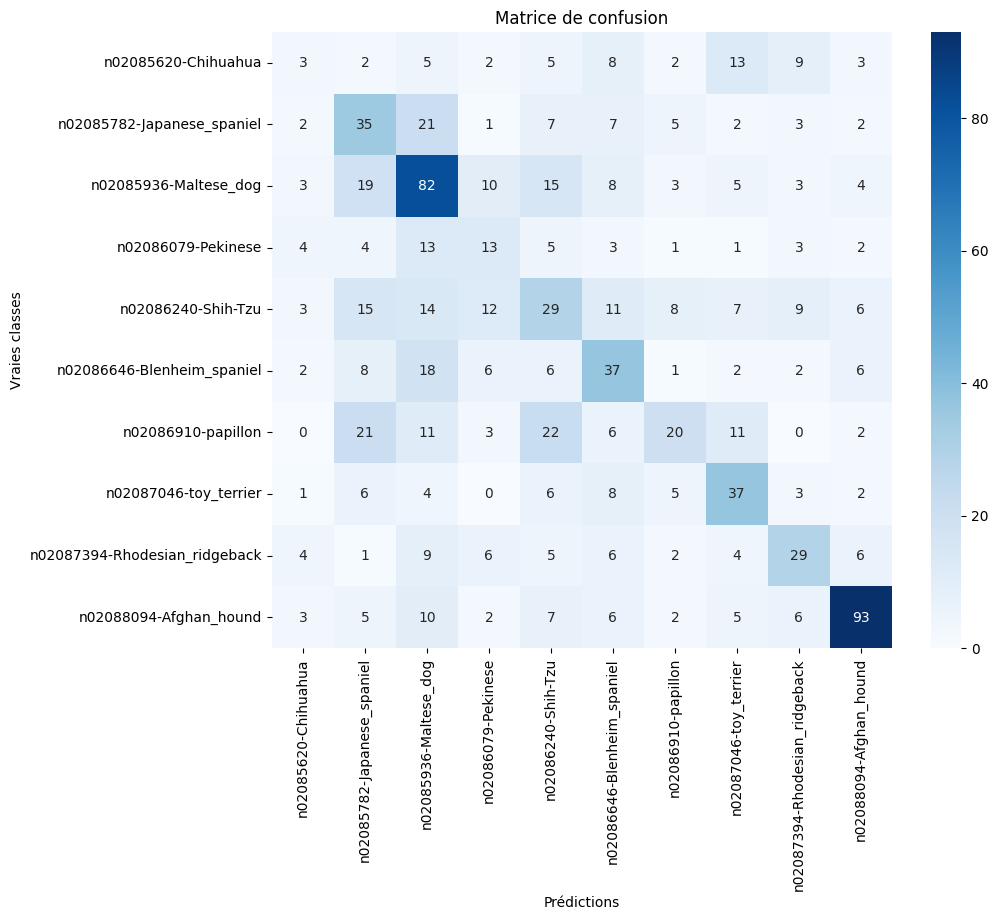

In [24]:
# Prédictions du modèle
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes
y_true_classes = np.argmax(y_test_cat, axis=1)  # Convertir les labels one-hot en classes

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")
plt.show()

### Conclusion MObilNetV2

Le modèle montre une progression claire sur l'ensemble d'entraînement, avec une précision qui passe de 35,5 % à environ 49,3 %. Cela signifie qu'il parvient à mieux identifier les images au fil du temps. Cependant, la précision sur le jeu de validation reste relativement stable autour de 37 à 41 %, sans réelle amélioration à partir de la huitième époque. Cette stagnation, combinée à une perte de validation qui ne diminue pas de façon significative, indique un début de surapprentissage : le modèle apprend les exemples d'entraînement mais ne généralise pas aussi bien sur les exemples qu'il n'a jamais vus.

L’examen de la matrice de confusion révèle plusieurs éléments importants. Certaines classes sont très bien apprises par le modèle. Par exemple, la race "Maltese_dog" est correctement identifiée dans 82 cas, et la race "Afghan_hound" dans 93 cas. Cela suggère que les caractéristiques visuelles de ces chiens sont bien captées par le réseau.

En revanche, plusieurs races proches sont régulièrement confondues entre elles. C’est le cas notamment des races "Japanese_spaniel", "Blenheim_spaniel", "Papillon" ou encore "Shih-Tzu", qui sont toutes des chiens de petite taille avec un pelage long et parfois un museau court. Le modèle semble avoir du mal à distinguer ces caractéristiques fines, ce qui conduit à des confusions fréquentes.

Enfin, la race "Rhodesian_ridgeback", qui est un chien de grande taille, est elle aussi souvent confondue avec des races de gabarit bien différent. Cela montre que le modèle n'exploite pas encore pleinement les indices de forme ou de proportions dans les images.

Le modèle est donc capable d’apprendre à différencier certaines races, mais ses performances sont limitées par la complexité visuelle des données. Le surapprentissage semble apparaître après quelques époques, ce qui suggère qu’une régularisation ou une augmentation des données pourrait être bénéfique. Par ailleurs, les confusions fréquentes entre races visuellement proches indiquent que le modèle gagnerait en efficacité en s’appuyant sur une architecture plus profonde. Ce type de solution pourrait permettre d'extraire des représentations visuelles plus riches et plus discriminantes.

## MobilNetV2 version amélioré avec data-augmentation